# 03 · Evolución provincial y contexto — Pruebas APRENDER

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/santiagoriverti/analisis_pruebas_aprender/blob/main/03_provincias.ipynb)

Análisis **descriptivo** de **cómo cambió el desempeño de cada provincia en los dos últimos operativos comparables** y de
**qué cambió en su contexto** en ese mismo período (hogar, trayectoria, asistencia, estudio, trabajo, clima escolar y
sistema educativo). Sin econometría y **sin atribuir causas**.

Consume el dataset de [`00_consolidacion.ipynb`](00_consolidacion.ipynb): en **Colab** lee desde
*Mi unidad/`pruebas_aprender/parquet`*; en **local**, desde `datos_consolidados/`. No hace falta correr el 01 ni el 02.

## Qué se compara
- **Primaria 6° grado (Censal): 2023 → 2025** y **Secundaria 5-6° año (Censal): 2022 → 2024** — los dos últimos
  operativos de cada cohorte comparable. Áreas: Lengua y Matemática. Indicador: % **Satisfactorio + Avanzado**.
- Son los períodos que describen las cuatro afirmaciones de partida: (1) en Lengua Primaria mejoraron todas;
  (2) en Matemática Primaria no todas, con asimetría; (3) en Lengua Secundaria no todas, con asimetría;
  (4) en Matemática Secundaria — **no mejoraron todas** (ver A).

## Cómo está organizado
- **A.** Cambio de cada provincia (las cuatro afirmaciones, con detalle).
- **B.** El punto de partida importa: las que partían más abajo, ¿mejoraron más? (convergencia).
- **C.** Comparación con provincias de **nivel inicial similar** → criterio para "mejoró más / menos de lo esperable".
- **D.** Indicadores de contexto emparejados entre los dos años de cada cohorte.
- **E.** ¿Qué cambió en las 8 provincias que más mejoraron frente a las 8 que menos? (y correlación de rangos).
- **F.** Fichas por provincia: qué indicadores cambiaron más o menos que el país.
- **G.** Control de calidad (dato del Relevamiento Anual descartado).
- **H.** Lectura de resultados. **I.** Descarga de gráficos y tablas.

## Límites (verificados contra los datos)
- Son **asociaciones entre 24 provincias**, no relaciones causales. Con ~30 indicadores, algunas coincidencias aparecen
  por azar: leer patrones consistentes, no números sueltos.
- Varias preguntas **cambian de redacción, período o escala** entre años (p. ej. "¿te molestaron?" pasa de "últimos tres
  meses" a "este año"; las formas de resolver conflictos cambian de lista). Sus **niveles no son comparables**; sirven las
  diferencias **entre provincias** (todas enfrentan el mismo cambio de cuestionario).
- **Primaria 2025 no tiene diccionario** y el cuestionario cambió de numeración: jardín (`ap06`), repitencia (`ap07`),
  tiempo de viaje (`ap09`), libros (`ap24`) y autopercepción (`ap40a–c`) se identificaron por sus opciones y distribución.
  **No hay preguntas de clima escolar identificables en 2025.**
- **Relevamiento Anual:** la jornada completa/extendida por provincia es inconsistente entre años (sección G) y se excluye.
- **No están en estas bases** factores clave: tasa de participación en la prueba, días de clase y conflictos docentes,
  programas provinciales (p. ej. de alfabetización), cambios de régimen académico y formación docente.

---
## 0 · Setup y carga

In [1]:
import os, re, glob, shutil, unicodedata
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import pyarrow.dataset as pads

def in_colab():
    try:
        import google.colab  # noqa
        return True
    except ImportError:
        return False

if in_colab():
    from google.colab import drive
    drive.mount('/content/drive')
    OUT = '/content/drive/MyDrive/pruebas_aprender/parquet'
else:
    OUT = os.path.join(os.getcwd(), 'datos_consolidados')
assert os.path.isdir(os.path.join(OUT, 'aprender_long')), (
    f'No encuentro el dataset en {OUT}. Corré primero 00_consolidacion.ipynb.')

# Paleta y estilo: fondo claro, grilla y ejes recesivos; azul/rojo para cambios (+/−) con gris neutro al medio
SUPERFICIE, TINTA, TINTA_2, TENUE, GRILLA, EJE = '#fcfcfb', '#0b0b0b', '#52514e', '#898781', '#e1e0d9', '#c3c2b7'
AZUL, NARANJA, ROJO, NEUTRO = '#2a78d6', '#eb6834', '#e34948', '#f0efec'
DIVERGENTE = LinearSegmentedColormap.from_list('divergente', [ROJO, NEUTRO, AZUL])
plt.rcParams.update({
    'figure.dpi': 110, 'figure.facecolor': SUPERFICIE, 'axes.facecolor': SUPERFICIE, 'savefig.facecolor': SUPERFICIE,
    'font.family': 'sans-serif', 'font.sans-serif': ['Segoe UI', 'DejaVu Sans', 'Arial'],
    'text.color': TINTA, 'axes.labelcolor': TINTA_2, 'axes.edgecolor': EJE, 'axes.titlecolor': TINTA,
    'xtick.color': TENUE, 'ytick.color': TINTA_2, 'axes.grid': True, 'grid.color': GRILLA, 'grid.linewidth': 0.6,
    'axes.spines.top': False, 'axes.spines.right': False, 'axes.axisbelow': True})

# Carpeta de salida: gráficos a 300 dpi + Excel con las tablas (se descargan en un zip al final)
GRAF = os.path.abspath('graficos_provincias'); os.makedirs(GRAF, exist_ok=True)
def guardar(fig, nombre):
    fig.savefig(os.path.join(GRAF, nombre + '.png'), dpi=300, bbox_inches='tight')
    return fig
def nota(fig, texto):
    fig.text(0.01, -0.01, texto, fontsize=8, color=TENUE, ha='left', va='top')
print('Datos consolidados en:', OUT)
print('Salidas (gráficos 300 dpi + Excel) en:', GRAF)

Datos consolidados en: C:\Users\sriverti\Desktop\INECO\Repositorios\analisis_pruebas_aprender\datos_consolidados
Salidas (gráficos 300 dpi + Excel) en: C:\Users\sriverti\Desktop\INECO\Repositorios\analisis_pruebas_aprender\graficos_provincias


---
## 1 · Funciones y desempeño por provincia

In [2]:
def _n(s):
    s = unicodedata.normalize('NFKD', str(s)).encode('ascii', 'ignore').decode().lower()
    return re.sub(r'[^a-z0-9]+', ' ', s).strip()

# Nombres de provincia homogéneos entre años y entre APRENDER y el Relevamiento Anual
PROV_ALIAS = {'buenos aires': 'Buenos Aires', 'ciudad autonoma de buenos aires': 'CABA', 'ciudad de buenos aires': 'CABA',
              'tierra del fuego': 'Tierra del Fuego', 'tierra del fuego antartida e islas del atlantico sur': 'Tierra del Fuego'}
def norm_prov(s):
    return PROV_ALIAS.get(_n(s), str(s).strip())

ORDEN4 = ['Por debajo del básico', 'Básico', 'Satisfactorio', 'Avanzado']
def harmonizar_nivel(op):
    t = _n(op)
    if 'por debajo' in t: return 'Por debajo del básico'
    if t == 'basico': return 'Básico'
    if 'satisfactorio' in t: return 'Satisfactorio'
    if 'avanzado' in t: return 'Avanzado'
    return None

AREAS = ['Lengua', 'Matematica']
# Últimos dos operativos de cada cohorte comparable (misma nivel/grado/cobertura censal)
PARES = {'Primaria 6°':     dict(nivel='Primaria',   grado='6 grado', y0=2023, y1=2025),
         'Secundaria 5-6°': dict(nivel='Secundaria', grado='5-6 año', y0=2022, y1=2024)}
SERIES = [(coh, area) for coh in PARES for area in AREAS]
def etiqueta(coh, area):
    return f"{'Lengua' if area == 'Lengua' else 'Matemática'} {'Prim.' if coh.startswith('Prim') else 'Sec.'}"

def archivos(anio):
    return sorted(glob.glob(os.path.join(OUT, 'aprender_long', f'anio={anio}', '*.parquet')))

def satisf_avanz(nivel, grado, anio):
    """% Satisfactorio+Avanzado por área y provincia, y total país (conteos ponderados)."""
    f = ((pads.field('tipo_variable') == 'desempeño') & (pads.field('cobertura') == 'Censal')
         & (pads.field('nivel') == nivel) & (pads.field('grado') == grado))
    d = (pads.dataset(archivos(anio), format='parquet')
         .to_table(filter=f, columns=['area', 'jurisdiccion', 'variable', 'valor']).to_pandas())
    d = d[d.area.isin(AREAS)].copy()
    d['nivel_desemp'] = d.variable.str.split('_', n=1).str[1].map(harmonizar_nivel)
    d = d.dropna(subset=['nivel_desemp'])
    d['provincia'] = d.jurisdiccion.map(norm_prov)
    t = d.groupby(['area', 'provincia', 'nivel_desemp']).valor.sum().unstack().reindex(columns=ORDEN4).fillna(0)
    tn = d.groupby(['area', 'nivel_desemp']).valor.sum().unstack().reindex(columns=ORDEN4).fillna(0)
    return (100 * (t['Satisfactorio'] + t['Avanzado']) / t.sum(axis=1),
            100 * (tn['Satisfactorio'] + tn['Avanzado']) / tn.sum(axis=1))

filas, NAC = [], {}
for coh, c in PARES.items():
    p0, n0 = satisf_avanz(c['nivel'], c['grado'], c['y0'])
    p1, n1 = satisf_avanz(c['nivel'], c['grado'], c['y1'])
    for area in AREAS:
        NAC[(coh, area)] = (n0[area], n1[area])
        dn = n1[area] - n0[area]
        for prov in sorted(set(p0[area].index) | set(p1[area].index)):
            a, b = p0[area].get(prov, np.nan), p1[area].get(prov, np.nan)
            filas.append(dict(cohorte=coh, area=area, provincia=prov, anio_inicial=c['y0'], anio_final=c['y1'],
                              inicial=a, final=b, delta=b - a, delta_vs_pais=(b - a) - dn))
DES = pd.DataFrame(filas)
assert DES.groupby(['cohorte', 'area']).provincia.nunique().eq(24).all() and DES.delta.notna().all()
print('Funciones listas. Provincias por serie:', DES.groupby(['cohorte', 'area']).provincia.nunique().to_dict())

Funciones listas. Provincias por serie: {('Primaria 6°', 'Lengua'): 24, ('Primaria 6°', 'Matematica'): 24, ('Secundaria 5-6°', 'Lengua'): 24, ('Secundaria 5-6°', 'Matematica'): 24}


---
## A · Cómo cambió cada provincia (afirmaciones 1 a 4)
Cambio en **puntos porcentuales (pp)** del % Satisfactorio + Avanzado entre los dos últimos operativos. La línea gris
oscura marca el cambio del país.

> **Afirmación 4:** en Matemática Secundaria **no mejoraron todas** — 16 de 24 suben y 8 bajan; los cambios son muy
> chicos (casi todos dentro de ±2 pp, con niveles de 8–35 %) y el % "Por debajo del básico" sube en la mayoría.

In [3]:
resumen = []
for coh, area in SERIES:
    s = DES[(DES.cohorte == coh) & (DES.area == area)]
    n0, n1 = NAC[(coh, area)]
    resumen.append({'serie': f'{coh} · {area}', 'años': f'{s.anio_inicial.iloc[0]}→{s.anio_final.iloc[0]}',
                    'país inicial': n0, 'país final': n1, 'cambio país (pp)': n1 - n0,
                    'provincias que mejoran': f'{int((s.delta > 0).sum())} de {len(s)}',
                    'mínimo (pp)': s.delta.min(), 'máximo (pp)': s.delta.max(), 'desvío entre provincias (pp)': s.delta.std()})
RESUMEN = pd.DataFrame(resumen).round(1)
display(RESUMEN)

partes = []
for coh, area in SERIES:
    s = DES[(DES.cohorte == coh) & (DES.area == area)].set_index('provincia')
    lab = etiqueta(coh, area)
    partes.append(s[['inicial', 'final', 'delta']].rename(columns={
        'inicial': f'{lab} {s.anio_inicial.iloc[0]}', 'final': f'{lab} {s.anio_final.iloc[0]}', 'delta': f'{lab} Δ'}))
TABLA_A = pd.concat(partes, axis=1).round(1)
TABLA_A

,serie,años,país inicial,país final,cambio país (pp),provincias que mejoran,mínimo (pp),máximo (pp),desvío entre provincias (pp)
0,Primaria 6° · Lengua,2023→2025,66.4,76.9,10.5,24 de 24,7.3,13.9,2.0
1,Primaria 6° · Matematica,2023→2025,51.4,55.0,3.6,22 de 24,-3.7,6.3,2.4
2,Secundaria 5-6° · Lengua,2022→2024,56.9,56.9,-0.1,10 de 24,-5.1,3.3,2.1
3,Secundaria 5-6° · Matematica,2022→2024,17.6,17.6,-0.0,16 de 24,-4.5,3.2,1.6


,Lengua Prim. 2023,Lengua Prim. 2025,Lengua Prim. Δ,Matemática Prim. 2023,Matemática Prim. 2025,Matemática Prim. Δ,Lengua Sec. 2022,Lengua Sec. 2024,Lengua Sec. Δ,Matemática Sec. 2022,Matemática Sec. 2024,Matemática Sec. Δ
provincia,,,,,,,,,,,,
Buenos Aires,67.2,77.4,10.2,51.5,56.3,4.7,57.1,57.3,0.1,17.1,16.9,-0.2
CABA,80.8,88.1,7.3,70.3,74.5,4.3,70.8,71.2,0.4,37.2,34.8,-2.4
Catamarca,59.7,73.1,13.4,39.6,45.8,6.2,49.2,45.4,-3.7,8.3,8.6,0.3
Chaco,51.5,63.9,12.4,36.9,38.4,1.6,41.9,43.9,2.0,7.3,8.2,0.9
Chubut,70.2,81.9,11.7,51.5,56.0,4.5,61.1,60.3,-0.8,18.0,17.6,-0.5
Corrientes,61.2,74.2,13.0,47.2,51.3,4.2,49.5,51.2,1.7,10.2,10.6,0.4
Córdoba,74.7,82.4,7.7,62.9,64.3,1.4,64.9,63.7,-1.2,25.9,24.2,-1.8
Entre Ríos,64.5,77.3,12.8,48.0,53.5,5.6,58.0,61.3,3.3,17.0,18.2,1.2
Formosa,64.2,77.0,12.8,56.6,57.3,0.8,44.5,46.1,1.7,9.2,11.4,2.1


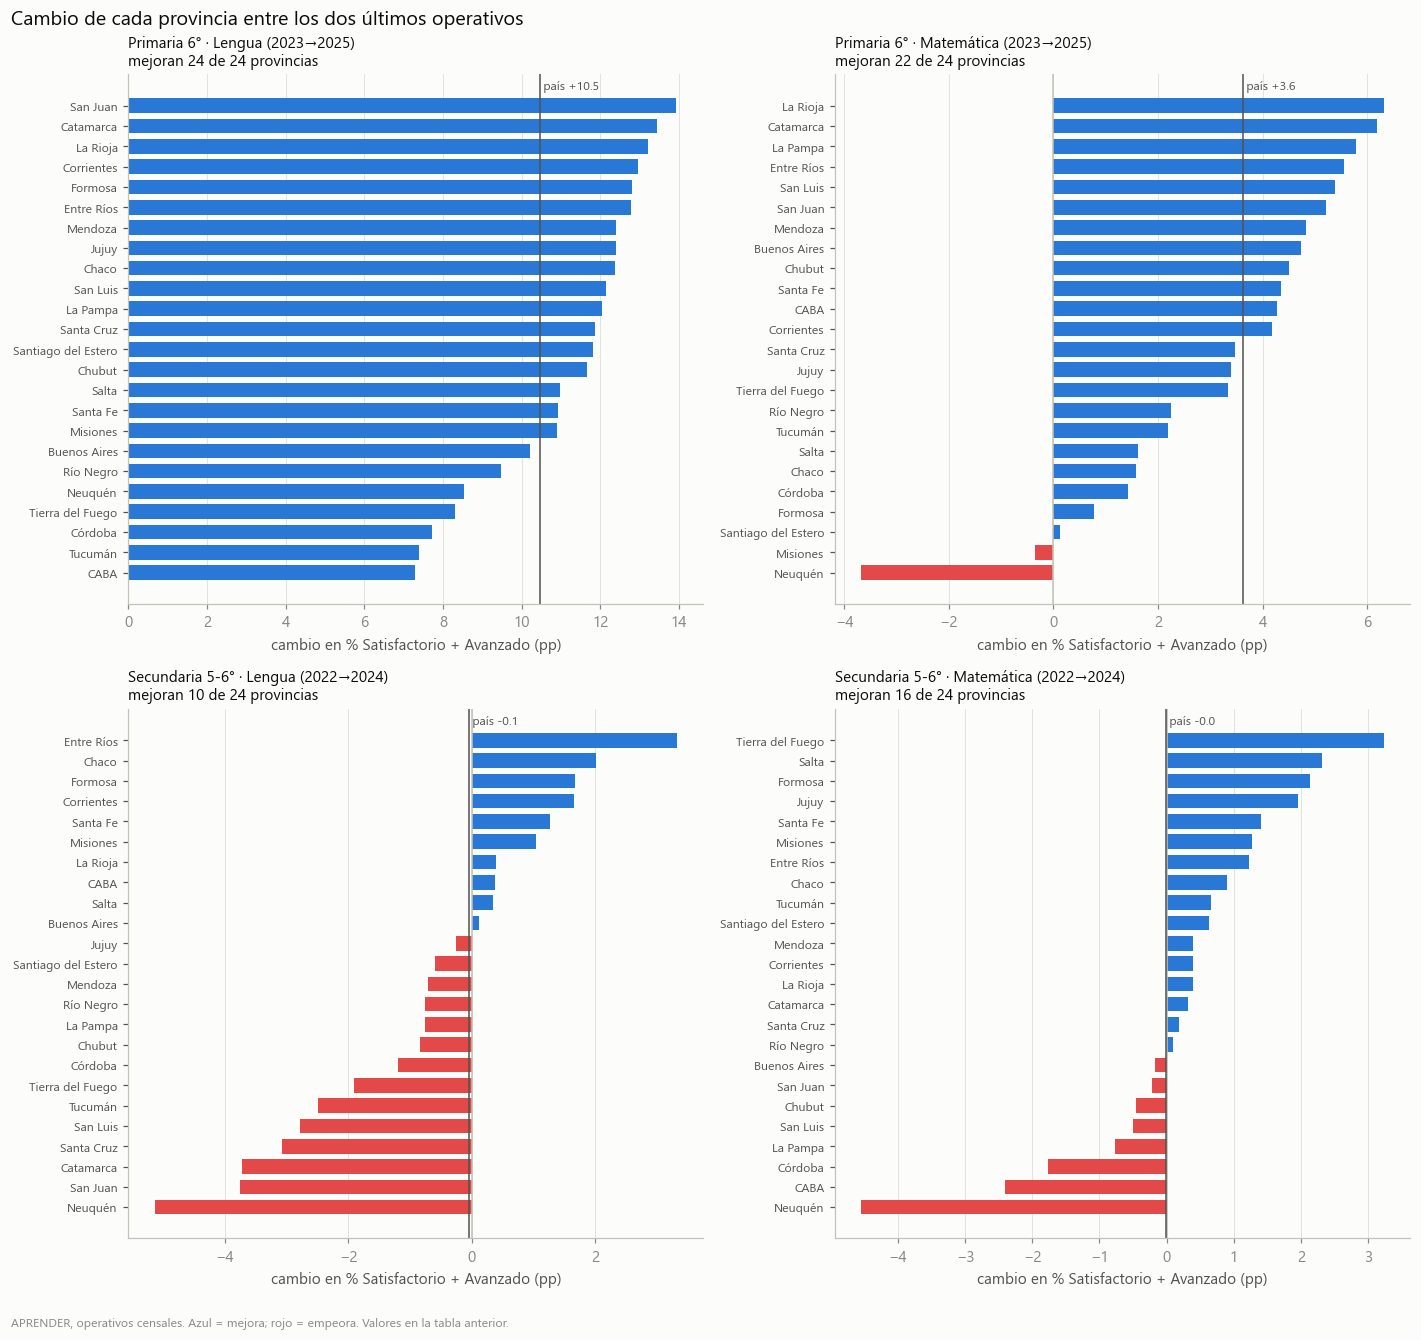

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 12))
for ax, (coh, area) in zip(axes.flat, SERIES):
    s = DES[(DES.cohorte == coh) & (DES.area == area)].sort_values('delta')
    n0, n1 = NAC[(coh, area)]; dn = n1 - n0
    ax.barh(s.provincia, s.delta, height=0.72, color=np.where(s.delta >= 0, AZUL, ROJO))
    ax.axvline(0, color=EJE, lw=1)
    ax.axvline(dn, color=TINTA_2, lw=1)
    ax.text(dn, len(s) - 0.35, f' país {dn:+.1f}', color=TINTA_2, fontsize=8, va='bottom')
    ax.grid(axis='y', visible=False); ax.tick_params(axis='y', labelsize=8)
    ax.set_title(f'{coh} · {"Matemática" if area == "Matematica" else area} ({s.anio_inicial.iloc[0]}→{s.anio_final.iloc[0]})\n'
                 f'mejoran {int((s.delta > 0).sum())} de {len(s)} provincias', loc='left', fontsize=10)
    ax.set_xlabel('cambio en % Satisfactorio + Avanzado (pp)')
fig.suptitle('Cambio de cada provincia entre los dos últimos operativos', fontsize=13, x=0.01, ha='left')
fig.tight_layout()
nota(fig, 'APRENDER, operativos censales. Azul = mejora; rojo = empeora. Valores en la tabla anterior.')
guardar(fig, 'A1_cambio_por_provincia'); plt.show()

---
## B · El punto de partida importa
Si las provincias que partían más abajo mejoran más (o caen menos), comparar el cambio "en bruto" favorece a las
rezagadas y penaliza a las de nivel alto (que además tienen menos margen). Se mide con la **correlación de rangos de
Spearman (ρ)** entre el cambio y el nivel inicial (negativa = convergencia) y con el cambio medio por **tercil de nivel
inicial** (8 provincias por tercil).

In [5]:
def por_serie(g):
    g = g.copy()
    g['tercil_inicial'] = pd.qcut(g.inicial.rank(method='first'), 3, labels=['bajo', 'medio', 'alto'])
    g['delta_vs_pares'] = g.delta - g.groupby('tercil_inicial', observed=True).delta.transform('mean')
    return g
DES = pd.concat([por_serie(g) for _, g in DES.groupby(['cohorte', 'area'], sort=False)], ignore_index=True)

conv = []
for coh, area in SERIES:
    s = DES[(DES.cohorte == coh) & (DES.area == area)]
    m = s.groupby('tercil_inicial', observed=True).delta.mean()
    conv.append({'serie': f'{coh} · {area}', 'ρ (cambio vs nivel inicial)': s.delta.corr(s.inicial, method='spearman'),
                 'cambio medio · tercil bajo': m['bajo'], 'cambio medio · tercil medio': m['medio'],
                 'cambio medio · tercil alto': m['alto']})
CONV = pd.DataFrame(conv).round(2)
CONV

,serie,ρ (cambio vs nivel inicial),cambio medio · tercil bajo,cambio medio · tercil medio,cambio medio · tercil alto
0,Primaria 6° · Lengua,-0.59,12.00,11.38,10.06
1,Primaria 6° · Matematica,-0.21,3.09,3.95,2.65
2,Secundaria 5-6° · Lengua,-0.37,-0.00,-0.30,-1.66
3,Secundaria 5-6° · Matematica,-0.48,0.73,1.18,-1.08


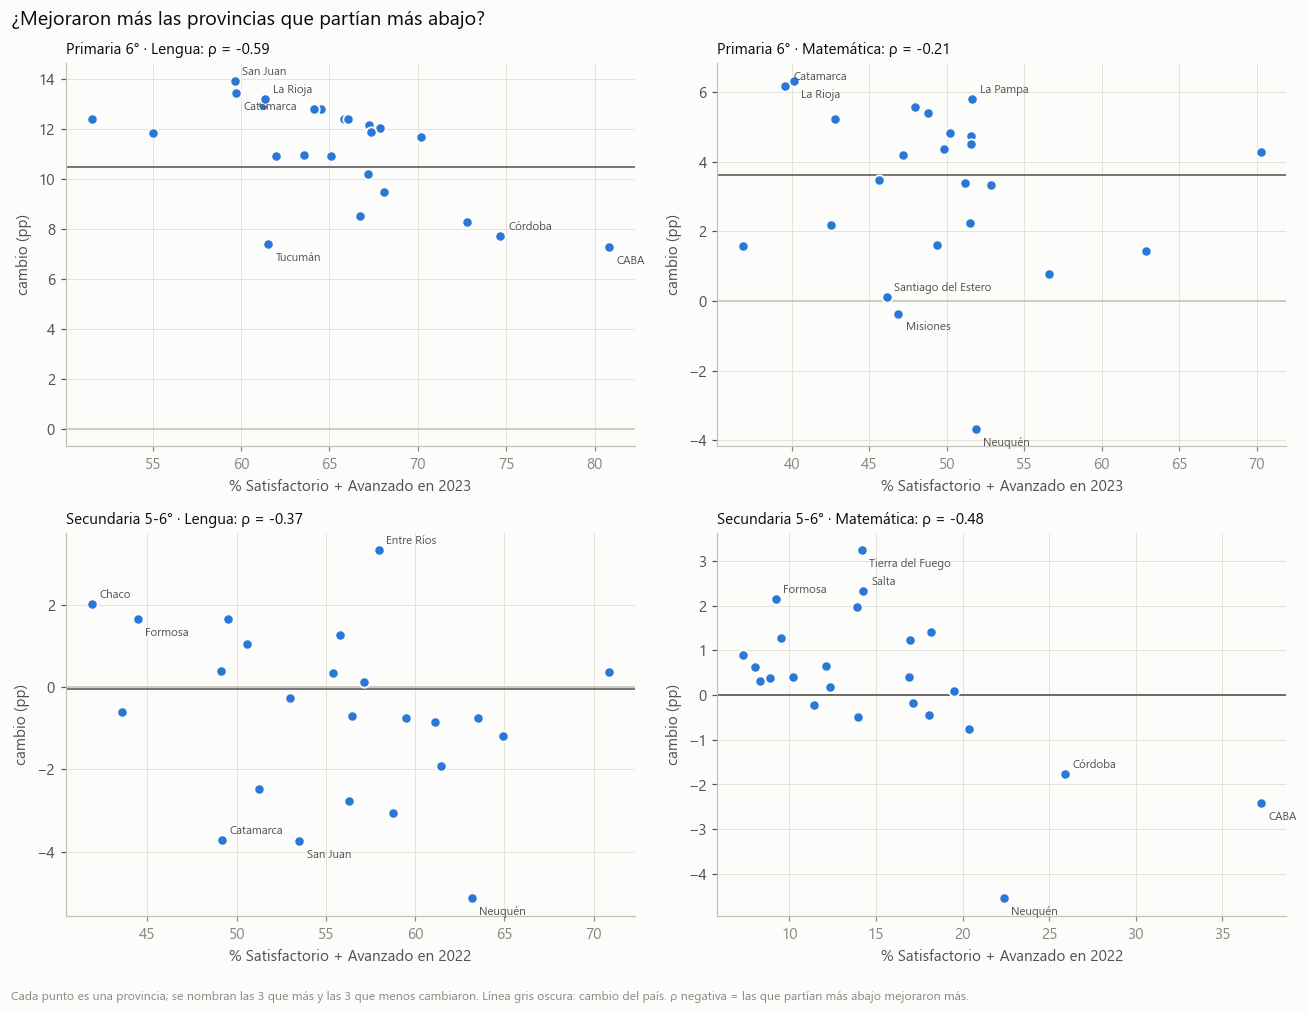

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, (coh, area) in zip(axes.flat, SERIES):
    s = DES[(DES.cohorte == coh) & (DES.area == area)]
    n0, n1 = NAC[(coh, area)]
    ax.axhline(0, color=EJE, lw=1); ax.axhline(n1 - n0, color=TINTA_2, lw=1)
    ax.scatter(s.inicial, s.delta, s=46, color=AZUL, edgecolor=SUPERFICIE, linewidth=1.2, zorder=3)
    marcadas = pd.concat([s.nlargest(3, 'delta'), s.nsmallest(3, 'delta')]).sort_values('inicial')
    for i, (_, r) in enumerate(marcadas.iterrows()):  # alterna arriba/abajo para que no se pisen nombres cercanos
        ax.annotate(r.provincia, (r.inicial, r.delta), xytext=(5, 4 if i % 2 == 0 else -11),
                    textcoords='offset points', fontsize=7.5, color=TINTA_2)
    rho = s.delta.corr(s.inicial, method='spearman')
    ax.set_title(f'{coh} · {"Matemática" if area == "Matematica" else area}: ρ = {rho:+.2f}', loc='left', fontsize=10)
    ax.set_xlabel(f'% Satisfactorio + Avanzado en {s.anio_inicial.iloc[0]}'); ax.set_ylabel('cambio (pp)')
fig.suptitle('¿Mejoraron más las provincias que partían más abajo?', fontsize=13, x=0.01, ha='left')
fig.tight_layout()
nota(fig, 'Cada punto es una provincia; se nombran las 3 que más y las 3 que menos cambiaron. Línea gris oscura: cambio del país. '
          'ρ negativa = las que partían más abajo mejoraron más.')
guardar(fig, 'B1_convergencia'); plt.show()

---
## C · Comparación con provincias de nivel inicial similar
Para cada serie, **cambio de la provincia − cambio medio de su tercil de nivel inicial** (pp). Es el criterio más justo para
decir qué provincias **mejoraron más o menos de lo esperable** dado su punto de partida. Se resume en el promedio de las
cuatro series y en cuántas series queda por encima de sus pares.

In [7]:
CONS = DES.pivot_table(index='provincia', columns=['cohorte', 'area'], values='delta_vs_pares')
CONS = CONS[[s for s in SERIES]]
CONS.columns = [etiqueta(c, a) for c, a in CONS.columns]
CONS['promedio'] = CONS.mean(axis=1)
CONS['series por encima de sus pares'] = (CONS.iloc[:, :4] > 0).sum(axis=1)
vs_pais = DES.pivot_table(index='provincia', columns=['cohorte', 'area'], values='delta_vs_pais')[[s for s in SERIES]]
vs_pais.columns = [f'vs país · {etiqueta(c, a)}' for c, a in vs_pais.columns]
CONS = CONS.join(vs_pais).sort_values('promedio', ascending=False)
CONS.round(1)

,Lengua Prim.,Matemática Prim.,Lengua Sec.,Matemática Sec.,promedio,series por encima de sus pares,vs país · Lengua Prim.,vs país · Matemática Prim.,vs país · Lengua Sec.,vs país · Matemática Sec.
provincia,,,,,,,,,,
Entre Ríos,1.4,1.6,3.6,0.0,1.7,4,2.3,1.9,3.4,1.2
La Pampa,2.0,3.1,0.9,0.3,1.6,4,1.6,2.2,-0.7,-0.8
Chubut,1.6,1.9,0.8,0.6,1.2,4,1.2,0.9,-0.8,-0.5
La Rioja,1.2,3.2,0.4,-0.3,1.1,3,2.7,2.7,0.4,0.4
Santa Fe,-0.4,0.4,1.6,2.5,1.0,3,0.5,0.7,1.3,1.4
Formosa,1.4,-1.9,1.7,1.4,0.7,3,2.3,-2.9,1.7,2.1
Corrientes,1.0,0.2,1.7,-0.3,0.6,3,2.5,0.6,1.7,0.4
Buenos Aires,-1.2,2.1,0.4,0.9,0.6,3,-0.3,1.1,0.2,-0.2
Jujuy,1.0,-0.5,0.0,0.8,0.3,3,1.9,-0.2,-0.2,2.0


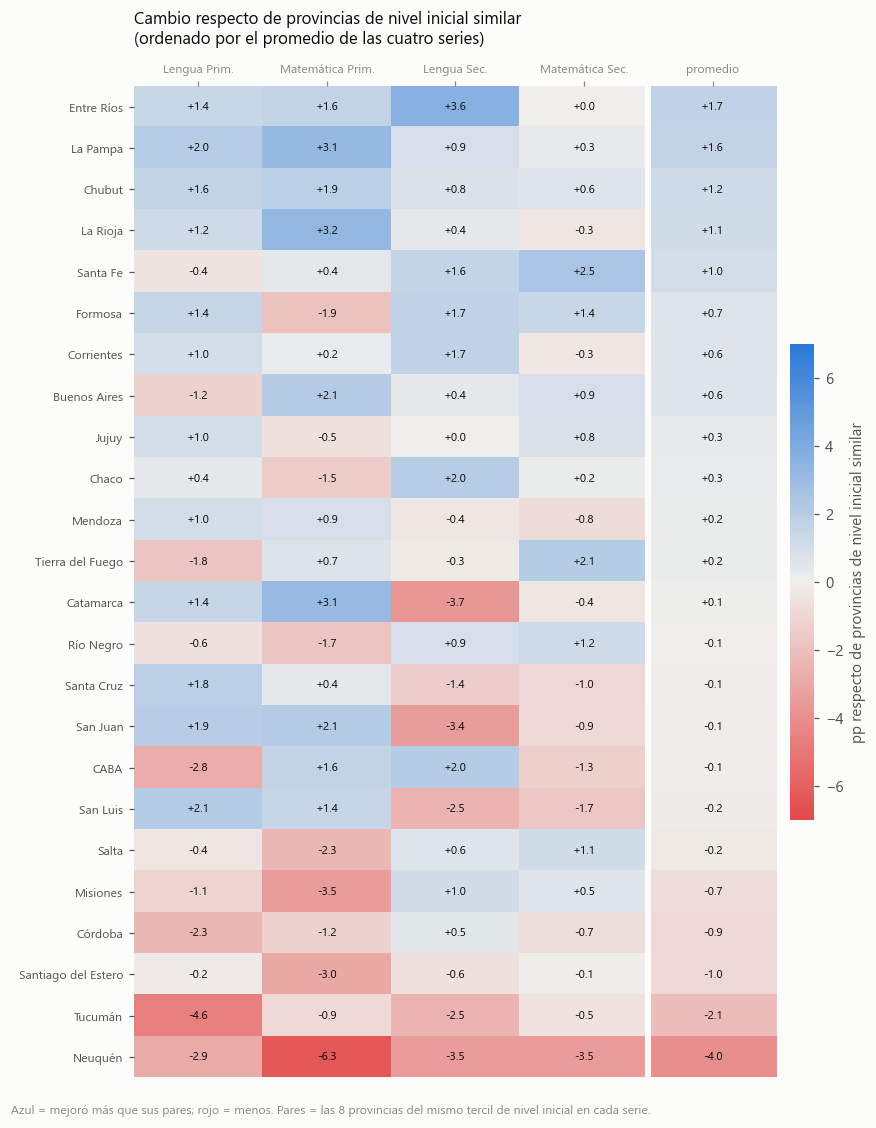

In [8]:
M = CONS.iloc[:, :5]
v = float(np.ceil(np.nanmax(np.abs(M.values))))
fig, ax = plt.subplots(figsize=(8, 10))
im = ax.imshow(M.values, aspect='auto', cmap=DIVERGENTE, vmin=-v, vmax=v)
ax.set_yticks(range(len(M))); ax.set_yticklabels(M.index, fontsize=8)
ax.set_xticks(range(M.shape[1])); ax.set_xticklabels(list(M.columns), fontsize=8)
ax.xaxis.tick_top(); ax.grid(False)
for spine in ax.spines.values(): spine.set_visible(False)
for (r, k), val in np.ndenumerate(M.values):
    ax.text(k, r, f'{val:+.1f}', ha='center', va='center', fontsize=7.5, color=TINTA)
ax.axvline(3.5, color=SUPERFICIE, lw=4)
cb = fig.colorbar(im, ax=ax, fraction=.035, pad=.02); cb.set_label('pp respecto de provincias de nivel inicial similar')
cb.outline.set_visible(False)
ax.set_title('Cambio respecto de provincias de nivel inicial similar\n(ordenado por el promedio de las cuatro series)',
             loc='left', fontsize=11, pad=28)
fig.tight_layout()
nota(fig, 'Azul = mejoró más que sus pares; rojo = menos. Pares = las 8 provincias del mismo tercil de nivel inicial en cada serie.')
guardar(fig, 'C1_comparacion_con_pares'); plt.show()

---
## D · Indicadores de contexto emparejados entre años
Cada indicador es el **% de estudiantes** (ponderado, cuestionario `Solo CC` del operativo censal) que responde la opción
indicada, emparejando la **misma pregunta** en los dos años aunque cambie su código. Se excluyen las respuestas en blanco,
multimarca o sin dato. Del **Relevamiento Anual (RA)** se suman indicadores del sistema para el año de cada operativo
(repitencia y abandono corresponden al ciclo lectivo anterior).

La tabla muestra los valores **del país**: los cambios muy grandes (p. ej. *Lo molestaron o dejaron de lado* +16 pp o
*Conflictos: se aplican sanciones* −28 pp en Secundaria) reflejan **cambios de redacción o período** de la pregunta, no del
contexto real. Por eso, en E y F se comparan provincias entre sí.

In [9]:
BLANCOS = {'Blanco', 'No_disponible', 'Multimarca', 'Dato_faltante'}
_cache_cc = {}
def cuestionario(anio, nivel, grado):
    k = (anio, nivel)
    if k not in _cache_cc:
        f = ((pads.field('area') == 'Solo CC') & (pads.field('cobertura') == 'Censal')
             & (pads.field('nivel') == nivel) & (pads.field('grado') == grado))
        d = (pads.dataset(archivos(anio), format='parquet')
             .to_table(filter=f, columns=['jurisdiccion', 'variable', 'valor']).to_pandas())
        d['provincia'] = d.jurisdiccion.map(norm_prov)
        sp = d.variable.str.split('_', n=1)
        d['codigo'], d['opcion'] = sp.str[0], sp.str[1]
        _cache_cc[k] = d
    return _cache_cc[k]

def pct(d, codigo, num=None, prefijo=None, excluir=None):
    x = d[d.codigo == codigo]
    assert len(x), f'código {codigo} sin datos'
    if prefijo: x = x[x.opcion.str.startswith(prefijo)]
    x = x[~x.opcion.isin(BLANCOS)]
    ops = set(x.opcion.unique())
    if excluir is not None:
        assert set(excluir) <= ops, f'{codigo}: opciones a excluir inexistentes {set(excluir) - ops}'
        m = ~x.opcion.isin(excluir)
    elif callable(num):
        m = x.opcion.map(num)
    else:
        assert set(num) <= ops, f'{codigo}: opciones inexistentes {set(num) - ops}'
        m = x.opcion.isin(num)
    assert m.any(), f'{codigo}: numerador vacío'
    tot = x.groupby('provincia').valor.sum()
    return (100 * x[m].groupby('provincia').valor.sum().reindex(tot.index).fillna(0) / tot,
            100 * x[m].valor.sum() / x.valor.sum())

SOBRE = lambda o: 'de_sobreedad' in o
SEL, SI = {'Selecciona'}, {'Sí'}
LIBROS20 = {'De_21_a_50_libros', 'De_51_a_100_libros', 'Más_de_100_libros'}
MADRE_SEC = {'Ed_Madre_Secundaria_completa', 'Ed_Madre_Terciario_universitario_posgrado_incompleto',
             'Ed_Madre_Terciario_universitario_posgrado_completo'}
NO_ESTUDIA = lambda o: o.startswith('No_estudié')
HS5 = {'Entre_5_y_7_horas', 'Entre_8_y_10_horas', 'Más_de_10_horas'}
# (grupo, indicador, especificación año inicial, especificación año final); especificación = dict para pct()
SPECS = {
 'Primaria 6°': [
  ('Trayectoria', 'Fue al jardín desde sala de 3 o antes', dict(codigo='ap21', num={'Sí_fui_al_jardín_desde_sala_de_3_o_antes'}), dict(codigo='ap06', num={'Sí_fui_al_jardín_desde_sala_de_3_o_antes'})),
  ('Trayectoria', 'Repitió algún grado', dict(codigo='ap22', num={'Sí_una_vez', 'Sí_dos_veces', 'Sí_tres_veces_o_más'}), dict(codigo='ap07', num={'Sí_una_vez', 'Sí_dos_veces_o_más'})),
  ('Trayectoria', 'Con sobreedad', dict(codigo='sobreedad', num=SOBRE), dict(codigo='sobreedad', num=SOBRE)),
  ('Hogar', 'Más de 20 libros en el hogar', dict(codigo='ap10', num=LIBROS20), dict(codigo='ap24', num={'21_a_50_libros', '51_a_100_libros', 'Más_de_100_libros'})),
  ('Hogar', 'Madre con terciario/universitario completo', dict(codigo='Nivel', num={'Ed_Madre_Terciario_universitario_posgrado_completo'}, prefijo='Ed_Madre_'), dict(codigo='Nivel', num={'Ed_Madre_Terciario_universitario_posgrado_completo'}, prefijo='Ed_Madre_')),
  ('Hogar', 'Madre con secundaria completa o más', dict(codigo='Nivel', num=MADRE_SEC, prefijo='Ed_Madre_'), dict(codigo='Nivel', num=MADRE_SEC, prefijo='Ed_Madre_')),
  ('Hogar', 'Familia migrante', dict(codigo='migracion', num={'Configuración_familiar_migrante'}), dict(codigo='migracion', num={'Configuración_familiar_migrante'})),
  ('Acceso', 'Tarda más de 30 min en llegar a la escuela', dict(codigo='ap26', num={'Entre_30_minutos_y_una_hora', 'Entre_una_hora_y_dos_horas', 'Más_de_dos_horas'}), dict(codigo='ap09', num={'Más_de_30_minutos'})),
  ('Autopercepción', 'Dice que lee muy bien', dict(codigo='ap27a', num={'Muy_bien'}), dict(codigo='ap40a', num={'Muy_bien'})),
  ('Autopercepción', 'Dice que escribe bien o muy bien', dict(codigo='ap27b', num={'Muy_bien', 'Bien'}), dict(codigo='ap40b', num={'Muy_bien', 'Bien'})),
  ('Autopercepción', 'Dice que resuelve cálculos bien o muy bien', dict(codigo='ap27c', num={'Muy_bien', 'Bien'}), dict(codigo='ap40c', num={'Muy_bien', 'Bien'})),
 ],
 'Secundaria 5-6°': [
  ('Hogar', 'Más de 20 libros en el hogar', dict(codigo='ap15', num=LIBROS20), dict(codigo='ap19', num=LIBROS20)),
  ('Hogar', 'Computadora en el hogar', dict(codigo='ap12g', num=SI), dict(codigo='ap16g', num=SI)),
  ('Hogar', 'Internet en el hogar', dict(codigo='ap12k', num=SI), dict(codigo='ap16k', num=SI)),
  ('Hogar', 'Espacio tranquilo para estudiar', dict(codigo='ap12a', num=SI), dict(codigo='ap15', num=SI)),
  ('Hogar', 'Madre con terciario/universitario completo', dict(codigo='Nivel', num={'Ed_Madre_Terciario_universitario_posgrado_completo'}, prefijo='Ed_Madre_'), dict(codigo='Nivel', num={'Ed_Madre_Terciariouniversitarioposgrado_completo'}, prefijo='Ed_Madre_')),
  ('Trayectoria', 'Repitió en ciclo básico', dict(codigo='ap25b', num={'Sí_una_vez', 'Sí_dos_veces'}), dict(codigo='ap25b', num={'Sí_una_vez', 'Sí_dos_o_más_veces'})),
  ('Trayectoria', 'Repitió en ciclo orientado', dict(codigo='ap25c', num={'Sí_una_vez', 'Sí_dos_veces'}), dict(codigo='ap25c', num={'Sí_una_vez', 'Sí_dos_o_más_veces'})),
  ('Trayectoria', 'Con sobreedad', dict(codigo='sobreedad', num=SOBRE), dict(codigo='sobreedad', num=SOBRE)),
  ('Asistencia', '20 o más inasistencias en el año', dict(codigo='ap26', num={'20_o_más_inasistencias'}), dict(codigo='ap27', num={'De_20_a_29_faltas', '30_o_más_faltas'})),
  ('Asistencia', 'Faltó por no tener ganas', dict(codigo='ap27e', num=SEL), dict(codigo='ap28d', num=SEL)),
  ('Asistencia', 'Faltó por llegar tarde', dict(codigo='ap27d', num=SEL), dict(codigo='ap28k', num=SEL)),
  ('Asistencia', 'Faltó por problemas de acceso', dict(codigo='ap27c', num=SEL), dict(codigo='ap28c', num=SEL)),
  ('Asistencia', 'Faltó por estar trabajando', dict(codigo='ap27i', num=SEL), dict(codigo='ap28j', num=SEL)),
  ('Estudio', 'No estudia fuera del horario escolar', dict(codigo='ap22', num=NO_ESTUDIA), dict(codigo='ap31', num=NO_ESTUDIA)),
  ('Estudio', 'Estudia 5 o más horas semanales fuera', dict(codigo='ap22', num=HS5), dict(codigo='ap31', num=HS5)),
  ('Trabajo', 'Trabaja para un empleador', dict(codigo='ap19a', excluir={'No_realicé_esta_tarea'}), dict(codigo='ap22b', excluir={'No_hice_estas_actividades'})),
  ('Trabajo', 'Cuida a familiares sin ayuda', dict(codigo='ap18b', excluir={'No_realicé_esta_tarea'}), dict(codigo='ap21b', excluir={'No_hice_estas_actividades'})),
  ('Clima', 'Vínculo muy bueno con profesores', dict(codigo='apB33c', num={'Muy_bueno'}), dict(codigo='ap35c', num={'Muy_bueno'})),
  ('Clima', 'Vínculo muy bueno con compañeros', dict(codigo='apB33a', num={'Muy_bueno'}), dict(codigo='ap35a', num={'Muy_bueno'})),
  ('Clima', 'Vínculo muy bueno con equipo directivo', dict(codigo='apB33e', num={'Muy_bueno'}), dict(codigo='ap35e', num={'Muy_bueno'})),
  ('Clima', 'Sufrió amenazas o agresión física/verbal', dict(codigo='apB34c', num=SI), dict(codigo='ap36c', num=SI)),
  ('Clima', 'Lo molestaron o dejaron de lado', dict(codigo='apB34a', num=SI), dict(codigo='ap36a', num=SI)),
  ('Clima', 'Conflictos: no se les da importancia', dict(codigo='apB36i', num=SEL), dict(codigo='ap38h', num=SEL)),
  ('Clima', 'Conflictos: se aplican sanciones', dict(codigo='apB36b', num=SEL), dict(codigo='ap38g', num=SEL)),
  ('Participación', 'Hay centro de estudiantes', dict(codigo='apB37a', num=SEL), dict(codigo='ap34a', num=SEL)),
  ('Participación', 'Estudiantes participan en normas de convivencia', dict(codigo='apB35c', num=SI), dict(codigo='ap33c', num=SI)),
  ('Familia', 'Familia apoya y ayuda con sus proyectos', dict(codigo='ap23', num={'Sí_me_apoya_y_me_ayuda_a_tomar_decisiones'}), dict(codigo='ap44', num={'Sí_me_apoya_y_me_ayuda_a_tomar_decisiones'})),
  ('Expectativas', 'Proyecta continuar estudios superiores', dict(codigo='apA34b', num=SEL), dict(codigo='ap43b', num=SEL)),
 ]}

def _num(df, cols):
    return df[cols].apply(pd.to_numeric, errors='coerce').fillna(0).sum(axis=1)

_cache_ra = {}
def ra_provincias(anio):
    """Indicadores del Relevamiento Anual por provincia y total país (columnas de texto convertidas a número)."""
    if anio in _cache_ra: return _cache_ra[anio]
    leer = lambda base: (lambda t: t[t.anio == anio])(pd.read_parquet(os.path.join(OUT, 'ra', f'ra_{base}.parquet')))
    m, t, cg = leer('matricula'), leer('trayectoria'), leer('cargos')
    P, S = range(1, 7), range(7, 13)
    x = pd.concat([
        pd.DataFrame({'provincia': m.provincia.map(norm_prov), 'mat_p': _num(m, [f'_{i}' for i in P]), 'sob_p': _num(m, [f's_{i}' for i in P]),
                      'mat_s': _num(m, [f'_{i}' for i in S]), 'sob_s': _num(m, [f's_{i}' for i in S])}).groupby('provincia').sum(),
        pd.DataFrame({'provincia': t.provincia.map(norm_prov),
                      'ini_p': _num(t, [f'inicial_{i}' for i in P]), 'rep_p': _num(t, [f'nopromo_{i}' for i in P]), 'ab_p': _num(t, [f'ssp_{i}' for i in P]),
                      'ini_s': _num(t, [f'inicial_{i}' for i in S]), 'rep_s': _num(t, [f'nopromo_{i}' for i in S]), 'ab_s': _num(t, [f'ssp_{i}' for i in S])}).groupby('provincia').sum(),
        pd.DataFrame({'provincia': cg.provincia.map(norm_prov), 'fte_cub': _num(cg, ['pri_fte_cub']), 'fte_ncub': _num(cg, ['pri_fte_ncub']),
                      'hs_cub': _num(cg, ['sec_hs_docente_cub']), 'hs_ncub': _num(cg, ['sec_hs_docente_ncub'])}).groupby('provincia').sum()], axis=1)
    def indicadores_ra(z):
        return pd.DataFrame({
            '% con sobreedad (primaria 1°–6°)': 100 * z.sob_p / z.mat_p,
            'repitencia primaria (ciclo anterior)': 100 * z.rep_p / z.ini_p,
            'abandono primaria (ciclo anterior)': 100 * z.ab_p / z.ini_p,
            'alumnos por cargo frente a alumnos (primaria)': z.mat_p / z.fte_cub,
            '% cargos frente a alumnos sin cubrir (primaria)': 100 * z.fte_ncub / (z.fte_cub + z.fte_ncub),
            '% con sobreedad (secundaria 7°–12°)': 100 * z.sob_s / z.mat_s,
            'repitencia secundaria (ciclo anterior)': 100 * z.rep_s / z.ini_s,
            'abandono secundaria (ciclo anterior)': 100 * z.ab_s / z.ini_s,
            'horas de clase por alumno (secundaria)': z.hs_cub / z.mat_s,
            '% horas de clase sin cubrir (secundaria)': 100 * z.hs_ncub / (z.hs_cub + z.hs_ncub)})
    _cache_ra[anio] = (indicadores_ra(x), indicadores_ra(x.sum().to_frame().T).iloc[0])
    return _cache_ra[anio]
RA_IND = {'Primaria 6°': ['% con sobreedad (primaria 1°–6°)', 'repitencia primaria (ciclo anterior)', 'abandono primaria (ciclo anterior)',
                          'alumnos por cargo frente a alumnos (primaria)', '% cargos frente a alumnos sin cubrir (primaria)'],
          'Secundaria 5-6°': ['% con sobreedad (secundaria 7°–12°)', 'repitencia secundaria (ciclo anterior)', 'abandono secundaria (ciclo anterior)',
                              'horas de clase por alumno (secundaria)', '% horas de clase sin cubrir (secundaria)']}

CTX = {}
for coh, c in PARES.items():
    y0, y1 = c['y0'], c['y1']
    d0, d1 = cuestionario(y0, c['nivel'], c['grado']), cuestionario(y1, c['nivel'], c['grado'])
    nac, v0, v1 = [], {}, {}
    for grupo, nombre, s0, s1 in SPECS[coh]:
        (p0, n0), (p1, n1) = pct(d0, **s0), pct(d1, **s1)
        k = f'{grupo} | {nombre}'; v0[k], v1[k] = p0, p1
        nac.append((grupo, nombre, n0, n1))
    (r0, rn0), (r1, rn1) = ra_provincias(y0), ra_provincias(y1)
    for nombre in RA_IND[coh]:
        k = f'Sistema (RA) | {nombre}'; v0[k], v1[k] = r0[nombre], r1[nombre]
        nac.append(('Sistema (RA)', nombre, rn0[nombre], rn1[nombre]))
    nac = pd.DataFrame(nac, columns=['grupo', 'indicador', f'país {y0}', f'país {y1}'])
    nac['cambio país'] = nac[f'país {y1}'] - nac[f'país {y0}']
    ini, fin = pd.DataFrame(v0), pd.DataFrame(v1)
    CTX[coh] = dict(nacional=nac, inicial=ini, final=fin, cambio=fin - ini)
    assert len(ini) == 24 and ini.notna().all().all(), f'{coh}: faltan provincias en los indicadores'
    print(f'\n{coh} {y0}→{y1}: {len(nac)} indicadores de contexto (valores del país)')
    display(nac.round(1))


Primaria 6° 2023→2025: 16 indicadores de contexto (valores del país)


,grupo,indicador,país 2023,país 2025,cambio país
0,Trayectoria,Fue al jardín desde sala de 3 o antes,57.6,61.4,3.8
1,Trayectoria,Repitió algún grado,12.8,7.1,-5.7
2,Trayectoria,Con sobreedad,10.5,12.5,2.1
3,Hogar,Más de 20 libros en el hogar,41.2,38.4,-2.7
4,Hogar,Madre con terciario/universitario completo,31.8,36.9,5.2
5,Hogar,Madre con secundaria completa o más,66.2,74.8,8.7
6,Hogar,Familia migrante,12.8,12.5,-0.3
7,Acceso,Tarda más de 30 min en llegar a la escuela,13.7,6.5,-7.1
8,Autopercepción,Dice que lee muy bien,41.2,45.8,4.6
9,Autopercepción,Dice que escribe bien o muy bien,76.3,78.3,2.0



Secundaria 5-6° 2022→2024: 33 indicadores de contexto (valores del país)


,grupo,indicador,país 2022,país 2024,cambio país
0,Hogar,Más de 20 libros en el hogar,40.4,41.6,1.2
1,Hogar,Computadora en el hogar,75.4,73.5,-1.8
2,Hogar,Internet en el hogar,93.3,95.5,2.2
3,Hogar,Espacio tranquilo para estudiar,82.9,84.4,1.5
4,Hogar,Madre con terciario/universitario completo,30.0,30.8,0.7
5,Trayectoria,Repitió en ciclo básico,13.2,8.3,-4.9
6,Trayectoria,Repitió en ciclo orientado,7.0,6.0,-1.0
7,Trayectoria,Con sobreedad,22.8,17.7,-5.1
8,Asistencia,20 o más inasistencias en el año,25.8,29.8,4.0
9,Asistencia,Faltó por no tener ganas,37.3,39.0,1.7


---
## E · ¿Qué cambió en las provincias que más y menos mejoraron?
Para cada serie: cambio medio de cada indicador en las **8 provincias que más mejoraron** frente a las **8 que menos**, y
la **correlación de rangos (ρ)** entre el cambio de desempeño y el cambio del indicador en las 24 provincias. También se
muestra la ρ con el **nivel inicial** del indicador (¿mejoraron más las que partían con más/menos de algo?).

**Cómo leerlo:** |ρ| < 0,4 es una asociación débil. Un indicador "explica" algo solo si el patrón se repite en varias
series y tiene sentido sustantivo; aun así, es una hipótesis a verificar con otras fuentes.

In [10]:
COMP = {}
for coh, area in SERIES:
    s = DES[(DES.cohorte == coh) & (DES.area == area)].set_index('provincia').sort_values('delta', ascending=False)
    cam, ini = CTX[coh]['cambio'].reindex(s.index), CTX[coh]['inicial'].reindex(s.index)
    top, bot = s.index[:8], s.index[-8:]
    t = pd.DataFrame({'cambio medio · 8 que más mejoran': cam.loc[top].mean(),
                      'cambio medio · 8 que menos mejoran': cam.loc[bot].mean()})
    t['diferencia'] = t.iloc[:, 0] - t.iloc[:, 1]
    t['ρ (cambio desempeño vs cambio indicador)'] = cam.apply(lambda col: s.delta.corr(col, method='spearman'))
    t['ρ (cambio desempeño vs nivel inicial del indicador)'] = ini.apply(lambda col: s.delta.corr(col, method='spearman'))
    COMP[(coh, area)] = t.sort_values('ρ (cambio desempeño vs cambio indicador)')
    print(f'\n### {coh} · {area}\n  Mejoran más: {", ".join(top)}\n  Mejoran menos: {", ".join(bot)}')
    display(COMP[(coh, area)].round(2))


### Primaria 6° · Lengua
  Mejoran más: San Juan, Catamarca, La Rioja, Corrientes, Formosa, Entre Ríos, Mendoza, Jujuy
  Mejoran menos: Misiones, Buenos Aires, Río Negro, Neuquén, Tierra del Fuego, Córdoba, Tucumán, CABA


,cambio medio · 8 que más mejoran,cambio medio · 8 que menos mejoran,diferencia,ρ (cambio desempeño vs cambio indicador),ρ (cambio desempeño vs nivel inicial del indicador)
Acceso | Tarda más de 30 min en llegar a la escuela,-10.06,-6.08,-3.98,-0.55,0.39
Hogar | Madre con terciario/universitario completo,4.54,5.45,-0.91,-0.25,-0.22
Hogar | Familia migrante,-0.78,-0.67,-0.11,-0.18,-0.42
Sistema (RA) | abandono primaria (ciclo anterior),0.02,0.06,-0.04,-0.11,0.21
Trayectoria | Con sobreedad,1.94,2.15,-0.21,0.02,0.44
Hogar | Más de 20 libros en el hogar,-0.18,-1.48,1.3,0.07,-0.58
Trayectoria | Repitió algún grado,-5.53,-5.51,-0.02,0.09,0.43
Sistema (RA) | % cargos frente a alumnos sin cubrir (primaria),-0.32,-0.32,-0.0,0.17,0.04
Sistema (RA) | repitencia primaria (ciclo anterior),0.16,-0.08,0.23,0.17,0.38
Hogar | Madre con secundaria completa o más,8.59,8.12,0.47,0.18,-0.20



### Primaria 6° · Matematica
  Mejoran más: La Rioja, Catamarca, La Pampa, Entre Ríos, San Luis, San Juan, Mendoza, Buenos Aires
  Mejoran menos: Tucumán, Salta, Chaco, Córdoba, Formosa, Santiago del Estero, Misiones, Neuquén


,cambio medio · 8 que más mejoran,cambio medio · 8 que menos mejoran,diferencia,ρ (cambio desempeño vs cambio indicador),ρ (cambio desempeño vs nivel inicial del indicador)
Sistema (RA) | alumnos por cargo frente a alumnos (primaria),-1.15,-0.64,-0.5,-0.18,-0.25
Hogar | Más de 20 libros en el hogar,-1.59,-0.55,-1.04,-0.15,0.09
Hogar | Familia migrante,-0.83,-1.18,0.35,-0.03,-0.35
Autopercepción | Dice que lee muy bien,4.8,5.8,-1.0,-0.02,-0.35
Hogar | Madre con secundaria completa o más,8.6,8.76,-0.16,-0.00,0.32
Sistema (RA) | abandono primaria (ciclo anterior),0.01,0.1,-0.09,0.06,-0.29
Sistema (RA) | % cargos frente a alumnos sin cubrir (primaria),-0.04,-0.38,0.34,0.08,-0.09
Acceso | Tarda más de 30 min en llegar a la escuela,-8.04,-10.1,2.06,0.10,-0.16
Autopercepción | Dice que escribe bien o muy bien,2.27,1.92,0.35,0.19,-0.14
Sistema (RA) | repitencia primaria (ciclo anterior),0.05,-0.19,0.25,0.22,0.07



### Secundaria 5-6° · Lengua
  Mejoran más: Entre Ríos, Chaco, Formosa, Corrientes, Santa Fe, Misiones, La Rioja, CABA
  Mejoran menos: Córdoba, Tierra del Fuego, Tucumán, San Luis, Santa Cruz, Catamarca, San Juan, Neuquén


,cambio medio · 8 que más mejoran,cambio medio · 8 que menos mejoran,diferencia,ρ (cambio desempeño vs cambio indicador),ρ (cambio desempeño vs nivel inicial del indicador)
Hogar | Espacio tranquilo para estudiar,0.84,2.14,-1.3,-0.41,-0.03
Clima | Vínculo muy bueno con profesores,1.37,3.79,-2.42,-0.41,0.44
Clima | Vínculo muy bueno con equipo directivo,-0.02,1.72,-1.75,-0.40,0.53
Asistencia | Faltó por no tener ganas,0.29,2.64,-2.35,-0.35,-0.34
Clima | Vínculo muy bueno con compañeros,1.77,3.02,-1.25,-0.30,0.35
Trayectoria | Con sobreedad,-4.72,-4.44,-0.28,-0.28,0.16
Clima | Sufrió amenazas o agresión física/verbal,2.84,3.53,-0.69,-0.27,0.26
Asistencia | 20 o más inasistencias en el año,2.08,2.0,0.09,-0.21,0.20
Asistencia | Faltó por estar trabajando,-0.13,0.28,-0.41,-0.17,0.40
Sistema (RA) | % horas de clase sin cubrir (secundaria),0.12,0.07,0.05,-0.15,-0.37



### Secundaria 5-6° · Matematica
  Mejoran más: Tierra del Fuego, Salta, Formosa, Jujuy, Santa Fe, Misiones, Entre Ríos, Chaco
  Mejoran menos: Buenos Aires, San Juan, Chubut, San Luis, La Pampa, Córdoba, CABA, Neuquén


,cambio medio · 8 que más mejoran,cambio medio · 8 que menos mejoran,diferencia,ρ (cambio desempeño vs cambio indicador),ρ (cambio desempeño vs nivel inicial del indicador)
Clima | Vínculo muy bueno con equipo directivo,-0.54,2.73,-3.27,-0.56,0.30
Participación | Estudiantes participan en normas de convivencia,5.77,10.39,-4.62,-0.53,0.13
Clima | Sufrió amenazas o agresión física/verbal,2.39,3.65,-1.26,-0.43,0.66
Trabajo | Trabaja para un empleador,-4.89,-3.89,-1.0,-0.40,0.34
Trayectoria | Con sobreedad,-5.08,-3.43,-1.64,-0.39,0.27
Estudio | No estudia fuera del horario escolar,-0.38,0.94,-1.32,-0.37,0.08
Clima | Vínculo muy bueno con compañeros,1.76,4.01,-2.25,-0.36,0.09
Clima | Vínculo muy bueno con profesores,2.19,4.62,-2.44,-0.32,0.23
Asistencia | 20 o más inasistencias en el año,1.36,3.72,-2.36,-0.31,-0.16
Participación | Hay centro de estudiantes,6.5,10.24,-3.74,-0.12,0.26


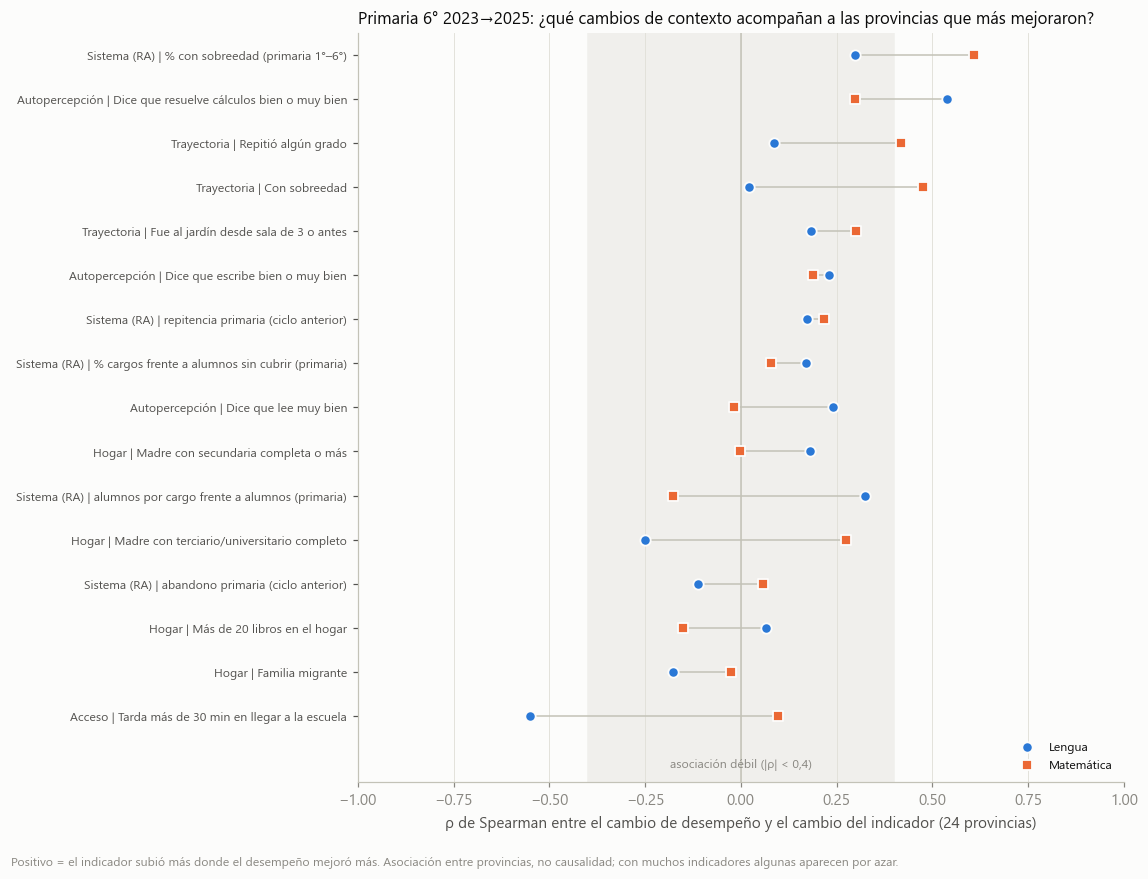

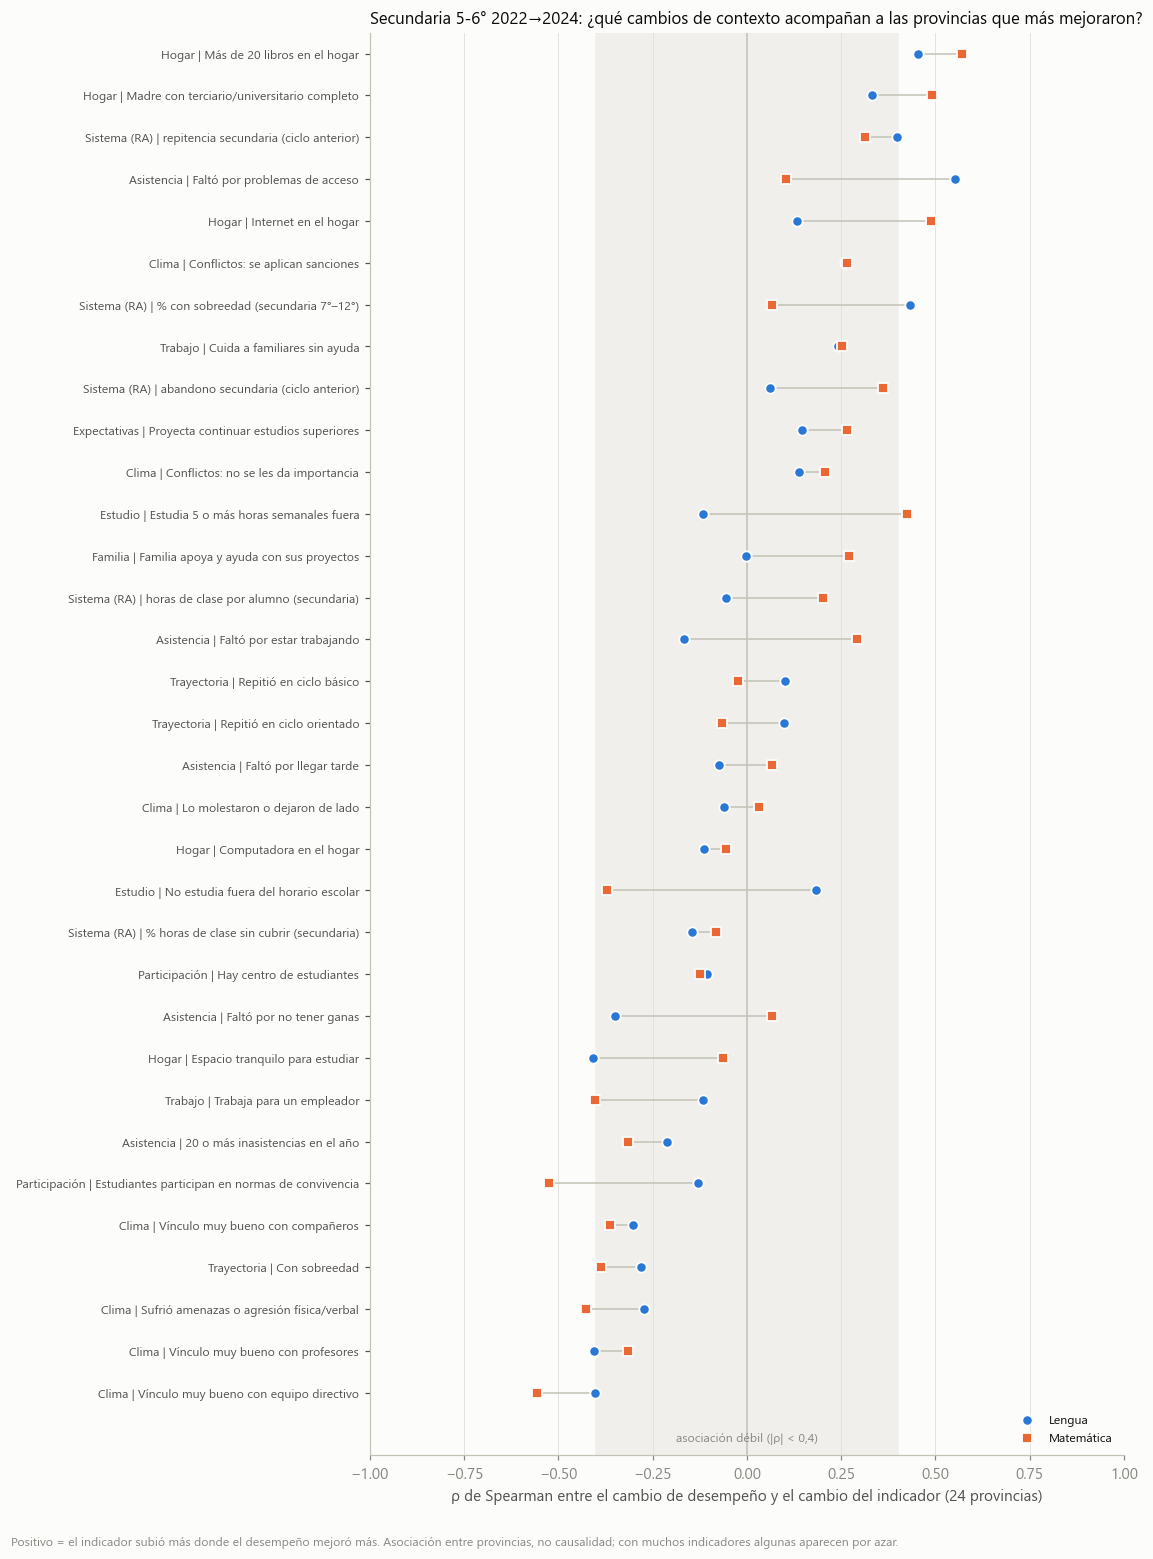

In [11]:
def grafico_rho(coh, archivo):
    rl = COMP[(coh, 'Lengua')]['ρ (cambio desempeño vs cambio indicador)']
    rm = COMP[(coh, 'Matematica')]['ρ (cambio desempeño vs cambio indicador)']
    orden = ((rl + rm.reindex(rl.index)) / 2).sort_values().index
    y = np.arange(len(orden))
    fig, ax = plt.subplots(figsize=(10.5, 0.36 * len(orden) + 2))
    ax.axvspan(-0.4, 0.4, color=NEUTRO, zorder=0)
    ax.axvline(0, color=EJE, lw=1)
    for i, k in enumerate(orden):
        ax.plot([rl[k], rm[k]], [i, i], color=EJE, lw=1, zorder=1)
    ax.scatter(rl[orden], y, s=46, marker='o', color=AZUL, edgecolor=SUPERFICIE, linewidth=1.2, label='Lengua', zorder=3)
    ax.scatter(rm[orden], y, s=46, marker='s', color=NARANJA, edgecolor=SUPERFICIE, linewidth=1.2, label='Matemática', zorder=3)
    ax.set_yticks(y); ax.set_yticklabels(orden, fontsize=8)
    ax.set_xlim(-1, 1); ax.set_ylim(-1.5, len(orden) - 0.5); ax.grid(axis='y', visible=False)
    ax.text(0, -1.1, 'asociación débil (|ρ| < 0,4)', ha='center', va='center', fontsize=8, color=TENUE)
    ax.set_xlabel('ρ de Spearman entre el cambio de desempeño y el cambio del indicador (24 provincias)')
    ax.legend(loc='lower right', frameon=False, fontsize=8)
    c = PARES[coh]
    ax.set_title(f'{coh} {c["y0"]}→{c["y1"]}: ¿qué cambios de contexto acompañan a las provincias que más mejoraron?',
                 loc='left', fontsize=11)
    fig.tight_layout()
    nota(fig, 'Positivo = el indicador subió más donde el desempeño mejoró más. Asociación entre provincias, no causalidad; '
              'con muchos indicadores algunas aparecen por azar.')
    guardar(fig, archivo); plt.show()

grafico_rho('Primaria 6°', 'E1_contexto_primaria')
grafico_rho('Secundaria 5-6°', 'E2_contexto_secundaria')

---
## F · Fichas por provincia
Cambio de cada indicador **menos el cambio del país** (pp; en *alumnos por cargo* y *horas por alumno*, en sus unidades).
Se listan los tres que más subieron y los tres que más bajaron **en relación con el país**. Provincias ordenadas por el
promedio de la sección C. La matriz completa queda en el Excel (hojas `rel_pais_*`).

In [12]:
REL, FICHAS = {}, {}
for coh in PARES:
    nac = CTX[coh]['nacional']
    rel = CTX[coh]['cambio'] - pd.Series(nac['cambio país'].values, index=nac.grupo + ' | ' + nac.indicador)
    filas = []
    for prov, r in rel.iterrows():
        r = r.dropna().sort_values()
        fmt = lambda serie: ' · '.join(f'{k.split(" | ")[1]} ({v:+.1f})' for k, v in serie.items())
        filas.append({'provincia': prov, 'subió más que el país': fmt(r[::-1].head(3)), 'bajó más que el país': fmt(r.head(3))})
    REL[coh], FICHAS[coh] = rel, pd.DataFrame(filas).set_index('provincia').reindex(CONS.index)
with pd.option_context('display.max_colwidth', None):
    for coh in PARES:
        print(f'\n### {coh}')
        display(FICHAS[coh])


### Primaria 6°


,subió más que el país,bajó más que el país
provincia,,
Entre Ríos,Repitió algún grado (+2.0) · % con sobreedad (primaria 1°–6°) (+1.6) · Más de 20 libros en el hogar (+1.3),Madre con terciario/universitario completo (-2.3) · Madre con secundaria completa o más (-1.9) · Familia migrante (-1.5)
La Pampa,Fue al jardín desde sala de 3 o antes (+4.7) · Madre con secundaria completa o más (+2.7) · Repitió algún grado (+1.9),Dice que lee muy bien (-4.5) · Dice que escribe bien o muy bien (-3.3) · Más de 20 libros en el hogar (-1.8)
Chubut,Dice que resuelve cálculos bien o muy bien (+4.7) · Dice que escribe bien o muy bien (+4.1) · Más de 20 libros en el hogar (+2.5),Madre con terciario/universitario completo (-1.1) · alumnos por cargo frente a alumnos (primaria) (-0.4) · Madre con secundaria completa o más (-0.1)
La Rioja,Fue al jardín desde sala de 3 o antes (+6.5) · Más de 20 libros en el hogar (+3.6) · Repitió algún grado (+1.8),Tarda más de 30 min en llegar a la escuela (-2.8) · Dice que escribe bien o muy bien (-0.3) · abandono primaria (ciclo anterior) (-0.1)
Santa Fe,Dice que lee muy bien (+2.5) · Dice que resuelve cálculos bien o muy bien (+2.4) · Dice que escribe bien o muy bien (+1.8),Más de 20 libros en el hogar (-1.7) · Con sobreedad (-0.2) · Familia migrante (-0.2)
Formosa,Más de 20 libros en el hogar (+2.2) · alumnos por cargo frente a alumnos (primaria) (+0.9) · Madre con secundaria completa o más (+0.5),Tarda más de 30 min en llegar a la escuela (-5.2) · Repitió algún grado (-3.2) · Madre con terciario/universitario completo (-3.1)
Corrientes,Más de 20 libros en el hogar (+3.6) · Dice que resuelve cálculos bien o muy bien (+3.0) · Dice que escribe bien o muy bien (+1.3),Tarda más de 30 min en llegar a la escuela (-7.4) · Con sobreedad (-2.9) · Repitió algún grado (-2.5)
Buenos Aires,Tarda más de 30 min en llegar a la escuela (+1.7) · Familia migrante (+0.7) · Fue al jardín desde sala de 3 o antes (+0.6),Más de 20 libros en el hogar (-2.7) · alumnos por cargo frente a alumnos (primaria) (-1.9) · Dice que resuelve cálculos bien o muy bien (-0.8)
Jujuy,Más de 20 libros en el hogar (+5.2) · Madre con terciario/universitario completo (+1.9) · Repitió algún grado (+1.3),Dice que lee muy bien (-2.3) · Dice que resuelve cálculos bien o muy bien (-0.8) · Tarda más de 30 min en llegar a la escuela (-0.5)



### Secundaria 5-6°


,subió más que el país,bajó más que el país
provincia,,
Entre Ríos,No estudia fuera del horario escolar (+3.3) · Repitió en ciclo básico (+3.0) · Conflictos: no se les da importancia (+2.6),Hay centro de estudiantes (-7.0) · Estudiantes participan en normas de convivencia (-5.8) · 20 o más inasistencias en el año (-4.5)
La Pampa,No estudia fuera del horario escolar (+3.1) · Conflictos: se aplican sanciones (+2.8) · Estudiantes participan en normas de convivencia (+2.3),Hay centro de estudiantes (-6.9) · Lo molestaron o dejaron de lado (-4.1) · Faltó por no tener ganas (-3.9)
Chubut,Faltó por llegar tarde (+4.7) · Faltó por no tener ganas (+4.4) · Vínculo muy bueno con profesores (+4.0),Faltó por problemas de acceso (-11.8) · repitencia secundaria (ciclo anterior) (-6.6) · Conflictos: se aplican sanciones (-5.9)
La Rioja,Hay centro de estudiantes (+9.3) · Más de 20 libros en el hogar (+4.5) · Repitió en ciclo básico (+3.2),Vínculo muy bueno con profesores (-5.6) · Computadora en el hogar (-4.8) · % con sobreedad (secundaria 7°–12°) (-3.6)
Santa Fe,Vínculo muy bueno con profesores (+6.0) · Vínculo muy bueno con compañeros (+5.9) · Más de 20 libros en el hogar (+4.5),Hay centro de estudiantes (-2.8) · Faltó por no tener ganas (-2.0) · Con sobreedad (-1.8)
Formosa,Repitió en ciclo básico (+2.0) · Conflictos: se aplican sanciones (+1.6) · Cuida a familiares sin ayuda (+1.3),Computadora en el hogar (-10.3) · Estudiantes participan en normas de convivencia (-5.3) · Vínculo muy bueno con profesores (-5.0)
Corrientes,Computadora en el hogar (+9.2) · repitencia secundaria (ciclo anterior) (+5.2) · Conflictos: se aplican sanciones (+4.4),Estudiantes participan en normas de convivencia (-7.2) · Vínculo muy bueno con compañeros (-3.9) · Vínculo muy bueno con equipo directivo (-3.8)
Buenos Aires,Faltó por problemas de acceso (+5.8) · Hay centro de estudiantes (+4.9) · Estudiantes participan en normas de convivencia (+3.9),Conflictos: se aplican sanciones (-3.9) · Repitió en ciclo orientado (-1.2) · Con sobreedad (-1.1)
Jujuy,Computadora en el hogar (+4.9) · Conflictos: se aplican sanciones (+3.2) · Más de 20 libros en el hogar (+2.9),Faltó por problemas de acceso (-6.4) · No estudia fuera del horario escolar (-4.2) · Estudiantes participan en normas de convivencia (-3.8)


---
## G · Control de calidad: jornada completa / extendida (Relevamiento Anual)
Se evaluó usar el % de alumnos de primaria en **jornada completa o extendida** como indicador de política. La serie por
provincia **no es consistente**: saltos de decenas de puntos en un año, valores que vuelven al nivel previo y hasta más
de 100 %. Parece un cambio en la forma de informar el dato, no en la oferta real, por lo que **se excluye** del análisis.

In [13]:
m = pd.read_parquet(os.path.join(OUT, 'ra', 'ra_matricula.parquet'), columns=['anio', 'provincia'] + [f'_{i}' for i in range(1, 7)])
po = pd.read_parquet(os.path.join(OUT, 'ra', 'ra_poblacion.parquet'),
                     columns=['anio', 'provincia', 'AlumnosenjornadacompletaPrimaria', 'AlumnosenjornadaextendidaPrimaria'])
m = m.assign(provincia=m.provincia.map(norm_prov), mat=_num(m, [f'_{i}' for i in range(1, 7)])).groupby(['provincia', 'anio']).mat.sum()
po = (po.assign(provincia=po.provincia.map(norm_prov), completa=_num(po, ['AlumnosenjornadacompletaPrimaria']),
                extendida=_num(po, ['AlumnosenjornadaextendidaPrimaria'])).groupby(['provincia', 'anio'])[['completa', 'extendida']].sum())
j = po.join(m).reset_index()
j = j[j.anio.between(2019, 2025)]
JORNADA = (100 * j.set_index(['provincia', 'anio'])[['completa', 'extendida']].div(j.set_index(['provincia', 'anio']).mat, axis=0))
JORNADA_EXT = JORNADA.extendida.unstack('anio')
salto = JORNADA_EXT.diff(axis=1).abs().max(axis=1)
print('Provincias con saltos de más de 20 pp en un año en % de jornada extendida:', int((salto > 20).sum()), 'de', len(salto))
JORNADA_EXT.loc[salto.sort_values(ascending=False).index].round(1)

Provincias con saltos de más de 20 pp en un año en % de jornada extendida: 7 de 24


anio,2019,2020,2021,2022,2023,2024,2025
provincia,,,,,,,
Santa Fe,6.6,6.5,6.7,6.7,77.1,12.1,113.5
Santa Cruz,0.0,0.0,0.0,97.1,88.3,1.2,1.2
Chaco,0.0,0.0,0.0,0.0,95.1,94.3,94.6
Tierra del Fuego,74.8,70.8,22.7,58.8,0.0,0.0,0.0
Tucumán,2.9,2.9,3.2,3.0,46.8,2.1,5.0
Jujuy,3.5,3.7,3.9,3.9,34.3,10.5,1.4
San Juan,4.3,4.3,3.5,4.0,10.6,38.7,36.9
Córdoba,39.1,38.5,40.0,37.5,54.5,57.6,60.6
Chubut,5.1,5.6,5.6,7.1,23.4,8.3,8.4


---
## H · Lectura de resultados (corrida 2026-09-15)

**1. Las cuatro afirmaciones.** Lengua Primaria mejora en las 24 provincias (+7,3 a +13,9 pp; país +10,5); Matemática
Primaria en 22 (bajan Neuquén −3,7 y Misiones −0,4); Lengua Secundaria en 10 (Entre Ríos +3,3 a Neuquén −5,1);
Matemática Secundaria en 16 de 24, **no en todas** (Tierra del Fuego +3,2 a Neuquén −4,6), con cambios muy chicos.

**2. El punto de partida pesa.** Las provincias que partían más abajo mejoraron más o cayeron menos: ρ = −0,59 en Lengua
Primaria, −0,48 en Matemática Secundaria, −0,37 en Lengua Secundaria y −0,21 en Matemática Primaria. En Lengua Primaria la
suba fue pareja en todo el país, lo que sugiere un factor **nacional** más que decisiones provinciales.

**3. Frente a provincias de nivel inicial similar** (sección C):
- **Por encima de lo esperable, de forma consistente:** Entre Ríos, La Pampa y Chubut (por encima de sus pares en las 4
  series; Entre Ríos es la mejor en Lengua Secundaria y en Matemática Secundaria queda prácticamente igual a sus pares),
  La Rioja y Santa Fe (3 de 4; Santa Fe se destaca en Secundaria).
- **Por debajo, de forma consistente:** **Neuquén** (0 de 4; la peor en tres series), **Tucumán** y Santiago del Estero
  (0 de 4) y **Córdoba** (1 de 4).
- **Mixtas:** Catamarca, San Juan y San Luis — muy buena Primaria, pero Lengua Secundaria claramente peor que sus pares.

**4. Contexto (asociaciones, no causas):**
- **Primaria:** la pista más coherente es la **asistencia al jardín desde sala de 3**, que creció más en La Rioja,
  Catamarca y San Juan, pero la asociación entre las 24 provincias es débil. La autopercepción acompaña los resultados
  (baja en CABA) más de lo que los explica. Los recursos docentes del RA no muestran relación. **No se puede evaluar el
  clima escolar** (no hay preguntas identificables en 2025).
- **Secundaria:** la señal más clara es la **composición del hogar** de quienes rindieron (más libros, madre con estudios
  superiores, internet donde Matemática mejoró más): parte del cambio puede deberse a **quién llegó a 5°-6° año y rindió**.
  Donde **subió la repitencia** registrada por el RA los resultados fueron mejores, y **Neuquén** combina la mayor baja
  relativa de repitencia con la peor caída (hipótesis: régimen académico / exigencia). Las provincias que mejoraron
  **perdieron menos horas de estudio** y **aumentaron menos las inasistencias altas**. El **clima escolar no acompaña** en
  este período: Córdoba y CABA mejoraron vínculos y cayeron; Chaco empeoró su clima y mejoró.

**Para indagar con otras fuentes:** tasas de participación en APRENDER por provincia; régimen académico y promoción en
secundaria (Neuquén, Entre Ríos, Chaco); días de clase efectivos y conflictos docentes 2022–2025; expansión de sala de 3 y
planes de alfabetización (La Rioja, Catamarca, San Juan); y, con los **microdatos 2024**, cuánto del desempeño secundario
por provincia se explica por la composición del hogar.

---
## I · Descargar gráficos y tablas
Guarda todas las tablas en `provincias_contexto.xlsx` dentro de `graficos_provincias/`, comprime la carpeta en un `.zip`
y, en **Colab**, **lo descarga**.

In [14]:
hojas = {'resumen': RESUMEN.set_index('serie'), 'desempeno_provincias': DES.set_index(['cohorte', 'area', 'provincia']),
         'tabla_A': TABLA_A, 'convergencia': CONV.set_index('serie'), 'comparacion_pares': CONS}
for coh, suf in [('Primaria 6°', 'prim'), ('Secundaria 5-6°', 'sec')]:
    hojas[f'ctx_nacional_{suf}'] = CTX[coh]['nacional'].set_index(['grupo', 'indicador'])
    for parte in ['inicial', 'final', 'cambio']:
        hojas[f'ctx_{parte}_{suf}'] = CTX[coh][parte]
    hojas[f'rel_pais_{suf}'] = REL[coh]
    hojas[f'fichas_{suf}'] = FICHAS[coh]
    for area, a in [('Lengua', 'leng'), ('Matematica', 'mate')]:
        hojas[f'contexto_{a}_{suf}'] = COMP[(coh, area)]
hojas['jornada_extendida_ra'] = JORNADA_EXT
ruta_xlsx = os.path.join(GRAF, 'provincias_contexto.xlsx')
with pd.ExcelWriter(ruta_xlsx, engine='openpyxl') as xw:
    for nombre, t in hojas.items():
        t = t.copy()
        num = t.select_dtypes('number').columns
        t[num] = t[num].round(3)
        t.to_excel(xw, sheet_name=nombre[:31])
print('Archivos a descargar:')
for n in sorted(os.listdir(GRAF)): print('  -', n)
zip_path = shutil.make_archive(os.path.join(os.path.dirname(GRAF), 'graficos_provincias'), 'zip', GRAF)
print('\nZIP:', zip_path, f'({os.path.getsize(zip_path)/1e6:.1f} MB)')
if in_colab():
    from google.colab import files
    files.download(zip_path)
    print('Descargando el zip...')
else:
    print('Entorno local: los archivos quedan en', GRAF)

Archivos a descargar:
  - A1_cambio_por_provincia.png
  - B1_convergencia.png
  - C1_comparacion_con_pares.png
  - E1_contexto_primaria.png
  - E2_contexto_secundaria.png
  - provincias_contexto.xlsx

ZIP: C:\Users\sriverti\Desktop\INECO\Repositorios\analisis_pruebas_aprender\graficos_provincias.zip (2.0 MB)
Entorno local: los archivos quedan en C:\Users\sriverti\Desktop\INECO\Repositorios\analisis_pruebas_aprender\graficos_provincias
